In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc

In [2]:
# 1. Load dataset
df = pd.read_csv('final_dance_dataset.csv')

# 2. Select features
features = [col for col in df.columns if any(axis in col for axis in ['x', 'y', 'z']) and 'frame' not in col]
X = df[features]

# 3. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

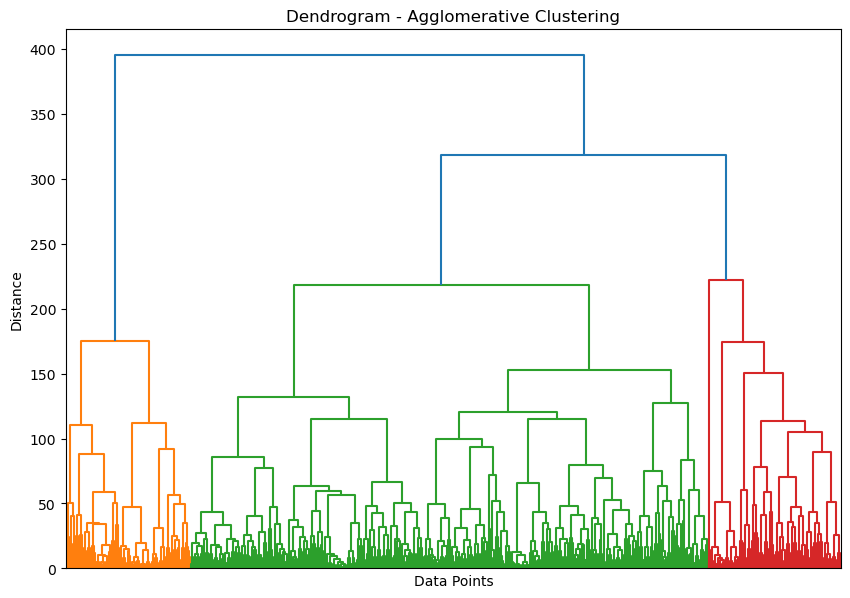

In [12]:
plt.figure(figsize=(10, 7))
plt.title('Dendrogram - Agglomerative Clustering')
shc.dendrogram(shc.linkage(X_scaled, method='ward'), no_labels=True)
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

In [8]:
model = AgglomerativeClustering(n_clusters=None, distance_threshold=250)
labels = model.fit_predict(X_scaled)

In [9]:
df['cluster_id'] = labels
# 10. Save
df.to_csv('Agglom_clusters.csv', index=False)
print("Final clustered dataset saved")

Final clustered dataset saved


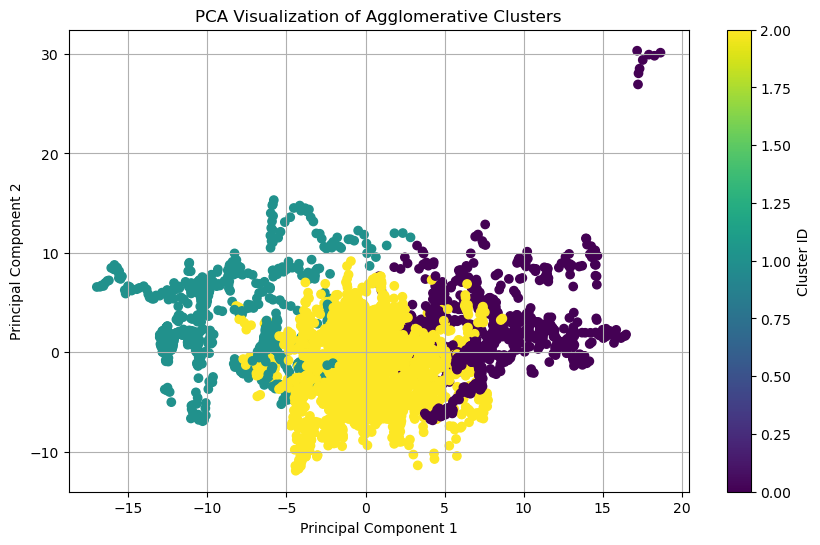

In [10]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_id'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Agglomerative Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('pca_clusters_agglom.png')
plt.show()

Running t-SNE...


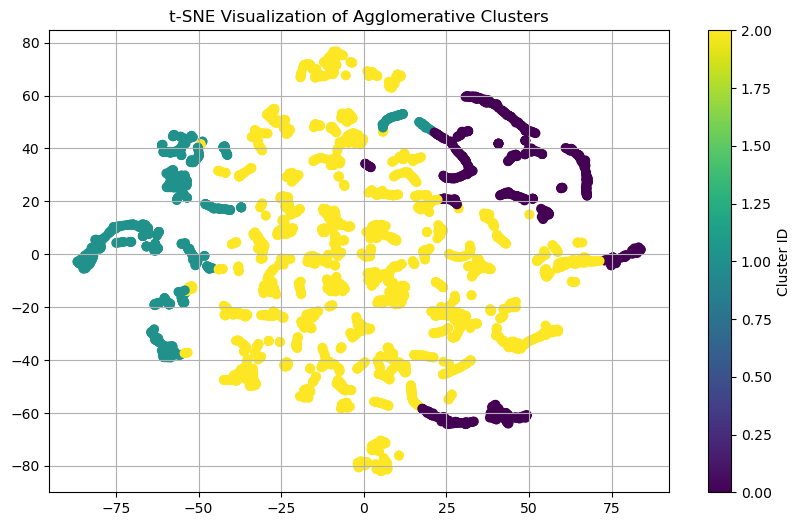

In [11]:
from sklearn.manifold import TSNE

print("Running t-SNE...")

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=df['cluster_id'])
plt.title('t-SNE Visualization of Agglomerative Clusters')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True)
plt.savefig('tsne_clusters_agglom.png')
plt.show()